# Import Data


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
BASE_DIR = "/content/drive/MyDrive/IndividualProject/cxr"
HDF5_PATH = f"{BASE_DIR}/images.hdf5"

In [3]:
import sys
import os

if os.path.exists("/content/drive"):
    # Google Colab
    PROJECT_ROOT = "/content/drive/MyDrive/IndividualProject"
else:
    # Local / GitHub
    PROJECT_ROOT = os.path.dirname(os.getcwd())

sys.path.append(os.path.join(PROJECT_ROOT, "src"))
from evaluation import youden_threshold, gender_disparity, auc_by_sex, age_disparity, auc_by_age, intersectional_disparity, auc_by_intersection

In [4]:
# import the required libraries
import numpy as np
import pandas as pd
import os
import ast

In [5]:
# import processed dataset
processed_df = pd.read_csv(BASE_DIR + "/processed_data_v3.csv")
processed_df.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/atelectasis_label,tasks/pneumonia_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,0,0
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0,0


Retrieve the train, validation and test splits.

In [6]:
# read the images in the train set
with open(BASE_DIR + "/splits/train.txt", "r") as f:
    train_list = [image_filepath.strip() for image_filepath in f]

# retrieve the entries in the train split and convert them into a DataFrame
train_df = processed_df[processed_df["filepath"].isin(train_list)]

# repeat the same process for validation set
with open(BASE_DIR + "/splits/val.txt", "r") as f:
    val_list = [image_filepath.strip() for image_filepath in f]

val_df = processed_df[processed_df["filepath"].isin(val_list)]

# repeat the same for test set
with open(BASE_DIR + "/splits/test.txt", "r") as f:
    test_list = [image_filepath.strip() for image_filepath in f]

test_df = processed_df[processed_df["filepath"].isin(test_list)]


# Adversarial Unlearning for Sex and Age


In [7]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import h5py
from PIL import Image
from tqdm import tqdm
from torch.autograd import Function
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve

In [8]:
class ChestXRayDataset(Dataset):

    def __init__(self, df, labels_col, hdf5_path, transform=None):
        self.df = df
        self.labels_col = labels_col
        self.hdf5_path = hdf5_path
        self.transform = transform

        self.h5 = h5py.File(self.hdf5_path, "r")
        self.images = self.h5["images"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        original_index = self.df.index[idx]
        img = self.images[original_index]
        img = torch.tensor(img, dtype=torch.float32)

        if img.max() > 1:
            img = img / 255.0

        img = img.unsqueeze(0).repeat(3,1,1)

        if self.transform:
            img = self.transform(img)

        y = float(self.df.iloc[idx][self.labels_col])
        label = torch.tensor([y], dtype=torch.float32)

        sex = float(self.df.iloc[idx]["tasks/patient sex"])
        sex_label = torch.tensor([sex], dtype=torch.float32)

        raw_age = self.df.iloc[idx]['patient_age']

        if raw_age >= 50:
          age_binary = 1
        else:
          age_binary = 0

        age = torch.tensor(float(age_binary), dtype=torch.float32)
        age = age.unsqueeze(0)

        return img, label, sex_label, age

In [9]:
# data augmentation process
from torchvision import transforms

# transform function for train set
train_transform = transforms.Compose([
    # perform horizontal flip, rotation and normalize
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

]
)

# trasform function for validation set
valid_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transform function for test set
test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [10]:
train_dataset = ChestXRayDataset(
    df = train_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = train_transform
)

valid_dataset = ChestXRayDataset(
    df = val_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = valid_transform
)

test_dataset = ChestXRayDataset(
    df = test_df,
    labels_col = 'tasks/atelectasis_label',
    hdf5_path=HDF5_PATH,
    transform = test_transform
)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 64,
    shuffle = False,
    num_workers = 0,
    pin_memory=True
)

In [12]:
# define Gradient Reversal Layer for adversarial training
# reference: https://discuss.pytorch.org/t/solved-reverse-gradients-in-backward-pass/3589/26
# reference: https://stackoverflow.com/questions/66814765/gradreverselayer-notimplementederror-you-must-implement-the-backward-function
# reference: https://github.com/fungtion/DANN/blob/master/models/functions.py
class ReverseLayerF(Function):

  @staticmethod
  def forward(ctx, x, lambd):
    ctx.lambd = lambd
    return x.view_as(x)

  # makes the gradient negative to make age prediction works
  @staticmethod
  def backward(ctx, grad_output):
    output = grad_output.neg() * ctx.lambd
    return output, None

# # the gradient reversal layer
# def grl(x, lambd):
#   return ReverseLayerF.apply(x, lambd)

In [13]:
class AdversarialDenseNet121(nn.Module):
  def __init__(self):
    super(AdversarialDenseNet121, self).__init__()
    # pretrained model - same as baseline
    backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    self.features = backbone.features
    feat_dim = backbone.classifier.in_features

    # predict atelectasis
    # disease classifier C (1 = has atelectasis)
    self.task_head = nn.Sequential(nn.Dropout(0.4), nn.Linear(feat_dim, 1))


    # predict sex
    # bias discriminator D
    self.sex_head = nn.Sequential(nn.Dropout(0.3),nn.Linear(feat_dim, 512),nn.ReLU(inplace=True),nn.Linear(512, 1))
    # self.sex_head = nn.Sequential(nn.Dropout(0.4), nn.Linear(feat_dim, 1))

    self.age_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(feat_dim, 512), nn.ReLU(inplace=True), nn.Linear(512, 1))

    # passes input image through DenseNet convolutional layers
  def extract(self, x):
    h = self.features(x)
    h = F.relu(h, inplace=True)
    h = F.adaptive_avg_pool2d(h, (1,1))
    h = h.view(h.size(0), -1)
    return h

  def forward(self, input_data, lambd):

    # extract feature vector
    feature = self.extract(input_data)
    reverse_feature = ReverseLayerF.apply(feature, lambd)

    # send the extracted h to effusion classifier (yes/no)
    task_output = self.task_head(feature)

    # send the extracted h to age classifier (male/female) - includes GRL layer
    sex_output = self.sex_head(reverse_feature)
    age_output =self.age_head(reverse_feature)
    return task_output, sex_output, age_output

In [14]:
# reference: https://github.com/Yangyangii/DANN-pytorch/blob/master/DANN.ipynb
def lambda_schedule(epoch, max_epoch, max_lambd):

  p = epoch/max_epoch
  return float(max_lambd * (2 / (1 + np.exp(-10 * p)) - 1))

In [15]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
model = AdversarialDenseNet121().to(DEVICE)

# pos_weight
pos = float((train_df["tasks/atelectasis_label"] == 1).sum())
neg = float((train_df["tasks/atelectasis_label"] == 0).sum())
pos_weight = torch.tensor([neg/ max(pos,1.0)], device =DEVICE)

# using binary cross entropy with logits loss
# criterion = nn.BCEWithLogitsLoss()
task_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# since it is not really imbalance so do not need pos_weight
sex_criterion = nn.BCEWithLogitsLoss()
age_criterion = nn.BCEWithLogitsLoss()

# num_features = model.classifier.in_features
# model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 1))
# model = model.to(DEVICE)

learning_rate = 5e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

Device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 185MB/s]


In [16]:
def train_one_epoch(model, loader, task_criterion, sex_criterion, age_criterion, optimizer, device, lambd):
  # use_amp = device.type == "cuda"

  model.train()
  training_loss, sex_loss, age_loss = 0.0, 0.0, 0.0
  loop = tqdm(loader, desc="Training", leave=False)

  for images, labels, sex, age in loop:
    images = images.to(device)
    labels = labels.to(device)
    sex = sex.to(device)
    age = age.to(device)
    age = age.float().view(-1, 1)

    # outputs = model(images)
      # compute the loss
    # loss = criterion(outputs, labels)
    optimizer.zero_grad()
    task_logit, sex_logit, age_logit = model(images, lambd=lambd)
    loss_task = task_criterion(task_logit, labels)
    loss_sex = sex_criterion(sex_logit, sex)
    loss_age = age_criterion(age_logit, age)

    loss = loss_task + loss_sex+ loss_age
    loss.backward()
    optimizer.step()

    training_loss += loss_task.item()
    sex_loss += loss_sex.item()
    age_loss += loss_age.item()

  avg_training_loss = training_loss/len(loader)
  avg_sex_loss = sex_loss/len(loader)
  avg_age_loss = age_loss/len(loader)

  return avg_training_loss, avg_sex_loss,avg_age_loss

In [17]:
def validate(model, loader, task_criterion, sex_criterion, age_criterion, device):
    model.eval()
    validation_loss, sex_loss, age_loss = 0.0, 0.0, 0.0
    validation_preds, validation_labels = [], []
    sex_preds, sex_labels = [], []
    age_preds, age_labels = [], []

    # disable gradient calculation
    with torch.no_grad():
      loop = tqdm(loader, desc="Validation", leave=False)

      for images, labels, sex, age in loop:
          images = images.to(device)
          labels = labels.to(device)
          sex = sex.to(device)
          age = age.to(device)
          age = age.float().view(-1, 1)

          task_logit, sex_logit, age_logit = model(images, lambd=0.0)
          validation_loss += task_criterion(task_logit, labels).item()
          sex_loss += sex_criterion(sex_logit, sex).item()
          age_loss += age_criterion(age_logit, age).item()

          validation_preds.append(torch.sigmoid(task_logit).cpu())
          validation_labels.append(labels.cpu())
          sex_preds.append(torch.sigmoid(sex_logit).cpu())
          sex_labels.append(sex.cpu())
          age_preds.append(torch.sigmoid(age_logit).cpu())
          age_labels.append(age.cpu())

    validation_preds = torch.cat(validation_preds).numpy().reshape(-1)
    validation_labels = torch.cat(validation_labels).numpy().reshape(-1)
    sex_preds = torch.cat(sex_preds).numpy().reshape(-1)
    sex_labels = torch.cat(sex_labels).numpy().reshape(-1)
    age_preds = torch.cat(age_preds).numpy().reshape(-1)
    age_labels = torch.cat(age_labels).numpy().reshape(-1)

    # compute the auc score directly
    valid_auc = roc_auc_score(validation_labels, validation_preds)
    sex_auc = roc_auc_score(sex_labels, sex_preds)
    age_auc = roc_auc_score(age_labels, age_preds)

    return validation_loss / len(loader), sex_loss/len(loader), age_loss/len(loader), validation_preds, validation_labels, sex_preds, sex_labels, age_preds, age_labels, valid_auc, sex_auc, age_auc

In [ ]:
def save_checkpoint(epoch, model, optimizer, learning_rate, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'learning_rate': learning_rate
    }
    torch.save(checkpoint, filename)

Main Training Loop


In [ ]:
from datetime import datetime

EPOCHS = 30
best_val = -1.0
patience = 5
min_delta = 0.001
epochs_no_improve = 0
training_loss, validation_loss, validation_auc = [], [], []
training_sex_loss, validation_sex_loss, validation_sex_auc = [], [], []
training_age_loss, validation_age_loss, validation_age_auc = [], [], []
lambd_values = []

# save for model checkpoint
for epoch in range(1, EPOCHS+1):
  lambd = lambda_schedule(epoch-1, EPOCHS, max_lambd=1.0)
  #  scaler
  train_loss, train_sex_loss, train_age_loss = train_one_epoch(model, train_loader, task_criterion, sex_criterion, age_criterion, optimizer, DEVICE, lambd)
  (val_loss, val_sex_loss, val_age_loss, val_preds, val_labels, sex_preds, sex_labels, age_preds, age_labels, val_auc, sex_auc, age_auc) = validate(model, valid_loader, task_criterion, sex_criterion, age_criterion, DEVICE)

  training_loss.append(train_loss)
  validation_loss.append(val_loss)
  validation_auc.append(val_auc)
  training_sex_loss.append(train_sex_loss)
  validation_sex_loss.append(val_sex_loss)
  validation_sex_auc.append(sex_auc)
  training_age_loss.append(train_age_loss)
  validation_age_loss.append(val_age_loss)
  validation_age_auc.append(age_auc)
  lambd_values.append(lambd)

  scheduler.step(val_auc)

  print(f"Epoch {epoch}/{EPOCHS} | λ={lambd:.3f} \n"
          f"Training Task Loss={train_loss:.4f}| Training Sex Loss={train_sex_loss:.4f} | Training age Loss={train_age_loss:.4f} \n"
          f"Validation Task Loss={val_loss:.4f}| Validation Sex Loss={train_sex_loss:.4f} | Validation age Loss={val_age_loss:.4f} \n"
          f"Val task AUC={val_auc:.4f} | Val sex AUC={sex_auc:.4f}| Val age AUC={age_auc:.4f}")

  # implement early stopping
  if val_auc > best_val + min_delta:
      best_val = val_auc
      best_epoch = epoch
      epochs_no_improve = 0
      timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
      torch.save(model.state_dict(), f"/content/drive/MyDrive/IndividualProject/best_model_binary_adversarial_atelectasis_sex_age_lambda1.pth")
  else:
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
          print(f"Early stopping: no val AUC improvement for {patience} epochs.")
          break

  save_checkpoint(epoch, model, optimizer, learning_rate, f"checkpoint_epoch_{epoch}.pth")

In [ ]:
# save the best result
import json
import os
from datetime import datetime

SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create training history dictionary
training_history = {
    'model_name': 'adversarial_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'hyperparameters': {
        'epochs': EPOCHS,
        'batch_size': 64,
        'learning_rate': learning_rate,
        'weight_decay': 1e-4,
        'optimizer': 'Adam',
        'scheduler': 'ReduceLROnPlateau',
        'patience': patience,
        'pos_weight': float(pos_weight.cpu().item()) if torch.is_tensor(pos_weight) else float(pos_weight)
    },
    'dataset_sizes': {
        'train': len(train_df),
        'validation': len(val_df),
        'test': len(test_df)
    },
    'training_curves': {
        'epochs': list(range(1, len(training_loss) + 1)),
        'train_loss': [float(x) for x in training_loss],
        'val_loss': [float(x) for x in validation_loss],
        'val_auc': [float(x) for x in validation_auc],
        'train_sex_loss': [float(x) for x in training_sex_loss],
        'val_sex_loss': [float(x) for x in validation_sex_loss],
        'val_sex_auc': [float(x) for x in validation_sex_auc],
        'train_age_loss': [float(x) for x in training_age_loss],
        'val_age_loss': [float(x) for x in validation_age_loss],
        'val_age_auc':[float(x) for x in validation_age_auc],
        'lambd': lambd_values
    },
    'best_model': {
        'epoch': best_epoch,
        'val_auc': float(max(validation_auc)),
        'val_loss': float(validation_loss[np.argmax(validation_auc)]),
        'val_sex_loss': float(validation_sex_loss[np.argmax(validation_auc)]),
        'val_sex_auc': float(validation_sex_auc[np.argmax(validation_auc)]),
        'val_age_auc': float(validation_age_auc[np.argmax(validation_auc)]),
        'val_age_loss': float(validation_age_loss[np.argmax(validation_auc)])
    },

    'early_stopping': {
        'triggered': epochs_no_improve >= patience,
        'stopped_at_epoch': len(training_loss)
    }
}

# Save as JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
history_file = f"{SAVE_DIR}/adversarial_training_history_atelectasis_sex_age_lambda1.json"
with open(history_file, 'w') as f:
    json.dump(training_history, f, indent=4)

# Graph Plotting

In [ ]:
import json
# load the json file
SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
with open(f"{SAVE_DIR}/adversarial_training_history_atelectasis_sex_age_lambda1.json", "r") as f:
  data = json.load(f)

In [ ]:
print(data["best_model"]["epoch"])

16


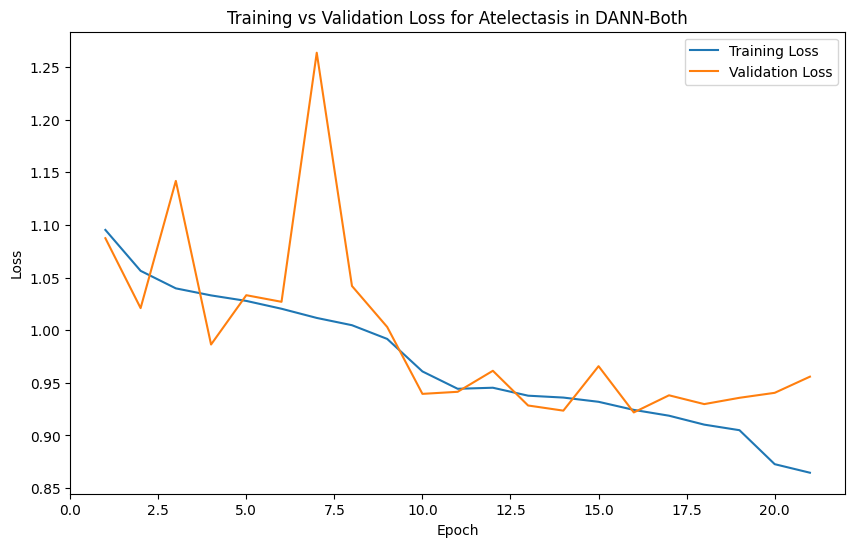

In [ ]:
# plot training vs validation loss for disease classifier
import matplotlib.pyplot as plt

training_loss = data["training_curves"]["train_loss"]
validation_loss = data["training_curves"]["val_loss"]

total_epochs = len(training_loss)

best_epoch = data["best_model"]["epoch"]
best_val_loss = data["best_model"]["val_loss"]

plt.figure(figsize=(10, 6))
plt.plot(range(1, total_epochs+1), training_loss, label="Training Loss")
plt.plot(range(1, total_epochs+1), validation_loss, label="Validation Loss")

# plt.scatter(best_epoch, best_val_loss, color='red', label='Best Epoch', zorder=5)
# plt.axvline(x=best_epoch, linestyle='--', color='red', alpha=0.7)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss for Atelectasis in DANN-Both")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/adversarial_training_vs_validation_loss_task_age{timestamp}.png")
plt.show()

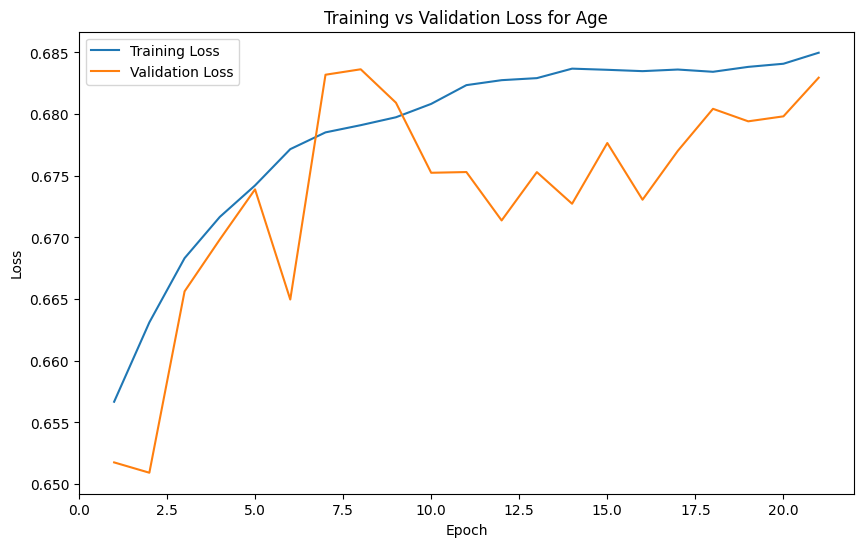

In [ ]:
# plot training vs validation loss for age classifier
import matplotlib.pyplot as plt

total_epochs = len(training_loss)

best_epoch = data["best_model"]["epoch"]
best_val_loss = data["best_model"]["val_loss"]

training_age_loss = data["training_curves"]["train_age_loss"]
validation_age_loss = data["training_curves"]["val_age_loss"]

plt.figure(figsize=(10, 6))
plt.plot(range(1, total_epochs+1), training_age_loss, label="Training Loss")
plt.plot(range(1, total_epochs+1), validation_age_loss, label="Validation Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss for Age")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/adversarial_training_vs_validation_loss_age_{timestamp}.png")
plt.show()

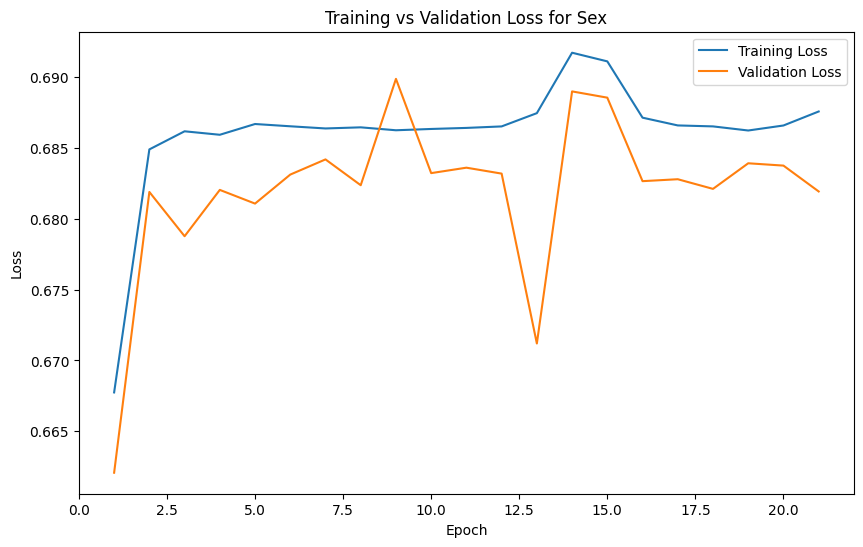

In [ ]:
# plot training vs validation loss for sex classifier
import matplotlib.pyplot as plt

total_epochs = len(training_loss)

best_epoch = data["best_model"]["epoch"]
best_val_loss = data["best_model"]["val_loss"]

training_sex_loss = data["training_curves"]["train_sex_loss"]
validation_sex_loss = data["training_curves"]["val_sex_loss"]

plt.figure(figsize=(10, 6))
plt.plot(range(1, total_epochs+1), training_sex_loss, label="Training Loss")
plt.plot(range(1, total_epochs+1), validation_sex_loss, label="Validation Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss for Sex")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/adversarial_training_vs_validation_loss_age_{timestamp}.png")
plt.show()

/tmp/ipykernel_6957/3082742981.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


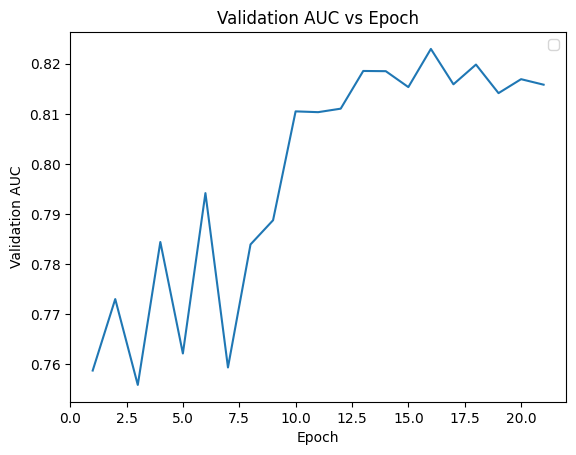

In [ ]:
# plot disease validation auc
validation_auc = data["training_curves"]["val_auc"]

plt.figure()
plt.plot(range(1, total_epochs+1), validation_auc)

plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC vs Epoch")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/adverarial_validation_auc_vs_epoch_task{timestamp}.png")
plt.show()

/tmp/ipykernel_6957/391832813.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


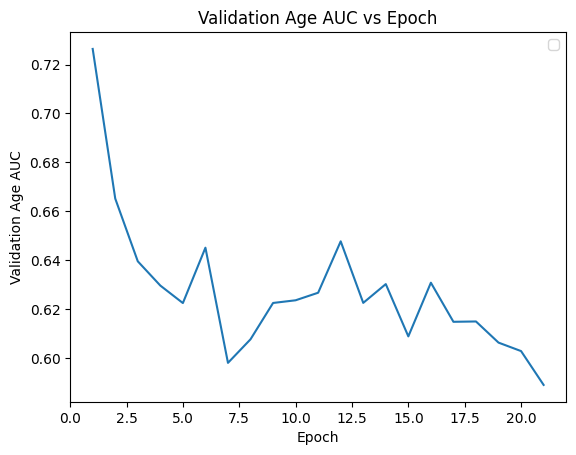

In [ ]:
# plot age validation auc
validation_age_auc = data["training_curves"]["val_age_auc"]
plt.figure()
plt.plot(range(1, total_epochs+1), validation_age_auc)

plt.xlabel("Epoch")
plt.ylabel("Validation Age AUC")
plt.title("Validation Age AUC vs Epoch")
plt.legend()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# plt.savefig(f"/content/drive/MyDrive/IndividualProject/results/figures/adverarial_validation_age_auc_vs_epoch_{timestamp}.png")
plt.show()

/tmp/ipykernel_6957/1637469972.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


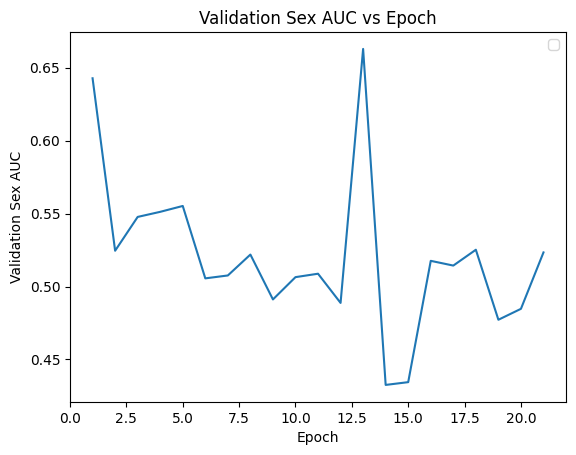

In [ ]:
# plot age validation auc
validation_sex_auc = data["training_curves"]["val_sex_auc"]
plt.figure()
plt.plot(range(1, total_epochs+1), validation_sex_auc)

plt.xlabel("Epoch")
plt.ylabel("Validation Sex AUC")
plt.title("Validation Sex AUC vs Epoch")
plt.legend()

# Evaluation

In [ ]:
# recreate the model
BEST_MODEL_PATH =  "/content/drive/MyDrive/IndividualProject/best_model_binary_adversarial_atelectasis_sex_age_lambda1.pth"

model = AdversarialDenseNet121().to(DEVICE)

best_model = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(best_model)
model.eval()

(val_loss, val_sex_loss, val_age_loss, val_preds, val_labels,
 sex_preds, sex_labels, age_preds, age_labels, val_auc, sex_auc, age_auc) = validate(model, valid_loader, task_criterion, sex_criterion, age_criterion, DEVICE)

best_threshold = youden_threshold(val_labels, val_preds)
print("Optimal threshold:", best_threshold)

(test_loss, test_sex_loss, test_age_loss, test_preds, test_labels,
 test_sex_preds, test_sex_labels, test_age_preds, test_age_labels, test_auc, test_sex_auc, test_age_auc) = validate(
    model, test_loader, task_criterion, sex_criterion, age_criterion, DEVICE)

# print out the result
print(f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f} | Sex AUC: {test_sex_auc:.4f}| Age AUC: {test_age_auc:.4f}")

test_sex_gap = gender_disparity(test_preds, test_labels, test_df, threshold=best_threshold)
print("Gender gap:", test_sex_gap)

test_auc_by_sex = auc_by_sex(test_preds, test_labels, test_df)
print("AUC by sex:", test_auc_by_sex)

# compute tpr
test_age_gap = age_disparity(test_preds, test_labels, test_df, threshold=best_threshold)
print("Age gap:", test_age_gap)

test_auc_by_age = auc_by_age(test_preds, test_labels, test_df)
print("AUC by age:", test_auc_by_age)


test_intersectional_tpr = intersectional_disparity(test_preds, test_labels, test_df, threshold = best_threshold)
print("Intersectional TPR disparity:", test_intersectional_tpr)

test_intersection_auc = auc_by_intersection(
    test_preds, test_labels, test_df)
print("Intersectional AUC:", test_intersection_auc)



Optimal threshold: 0.5030759


Test Loss: 1.2299 | Test AUC: 0.7501 | Sex AUC: 0.5501| Age AUC: 0.5775
Gender gap: {'atelectasis': {'tpr_male': 0.8194, 'tpr_female': 0.8034, 'tpr_disparity': 0.016, 'male_samples': 14882, 'female_samples': 10714, 'total_samples': 25596}}
AUC by sex: {'atelectasis': {'auc_male': 0.7616, 'auc_female': 0.7332, 'auc_gap': 0.0284, 'male_samples': 14882, 'female_samples': 10714, 'total_samples': 25596}}
Age gap: {'atelectasis': {'tpr_young': 0.7869, 'tpr_old': 0.8332, 'tpr_disparity': 0.0463, 'young_samples': 13167, 'old_samples': 12429, 'total_samples': 25596}}
AUC by age: {'atelectasis': {'auc_young': 0.7579, 'auc_old': 0.7384, 'auc_gap': -0.0194, 'young_samples': 13167, 'old_samples': 12429, 'total_samples': 25596}}
Intersectional TPR disparity: {'atelectasis': {'tpr_per_group': {'male_<50': 0.7871, 'male_>=50': 0.843, 'female_<50': 0.7865, 'female_>=50': 0.8182}, 'median_tpr': 0.8027, 'gap_per_group': {'male_<50': -0.0155, 'male_>=50': 0.0403, 'female_<50': -0.0162, 'female_>=50': 0.01

In [ ]:
import json
import pandas as pd
from datetime import datetime

# save reuslts
SAVE_DIR = "/content/drive/MyDrive/IndividualProject/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create results dictionary
baseline_results = {
    'model_name': 'adversarial_densenet121',
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'dataset_size': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'test_metrics': {
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'test_sex_loss': float(test_sex_loss),
        'test_sex_auc': float(test_sex_auc),
        'test_age_loss': float(test_age_loss),
        'test_age_auc': float(test_age_auc),
        'threshold': float(best_threshold)
    },
    'fairness_metrics': {
        'tpr_male': test_sex_gap['atelectasis']['tpr_male'],
        'tpr_female': test_sex_gap['atelectasis']['tpr_female'],
        'tpr_sex_disparity': test_sex_gap['atelectasis']['disparity'],
        'tpr_young': test_age_gap['atelectasis']['tpr_young'],
        'tpr_old': test_age_gap['atelectasis']['tpr_old'],
        'tpr_disparity': test_age_gap['atelectasis']['tpr_disparity'],
        'auc_male': test_auc_by_sex['atelectasis']['auc_male'],
        'auc_female': test_auc_by_sex['atelectasis']['auc_female'],
        'auc_gap': test_auc_by_sex['atelectasis']['auc_gap'],
        'auc_young': test_auc_by_age['atelectasis']['auc_young'],
        'auc_old': test_auc_by_age['atelectasis']['auc_old'],
        'auc_gap': test_auc_by_age['atelectasis']['auc_gap']
    },
    'sample_distribution': {
        'male_samples:': test_sex_gap['atelectasis']['male_samples'],
        'female_samples': test_sex_gap['atelectasis']['female_samples'],
        'total_samples': test_sex_gap['atelectasis']['total_samples'],
        'young_samples': test_age_gap['atelectasis']['young_samples'],
        'old_samples': test_age_gap['atelectasis']['old_samples'],
        'total_samples': test_age_gap['atelectasis']['total_samples']
    }
}

# Save as JSON
with open(f"{SAVE_DIR}/adversarial_results_actelatasis_youden_sex_age_lambda1.json", 'w') as f:
    json.dump(baseline_results, f, indent=4)
print(f"Results saved to {SAVE_DIR}/baseline_adversarial_results_actelatasis_youden_sex_age_lambda1.json")


# Sex Probing


In [ ]:
# define extract features functions
def extract_features(model, loader, device):

  model.eval()
  all_features = []
  all_labels = []
  all_sex = []

  with torch.no_grad():
    for imgs, labels, sex in loader:
      imgs = imgs.to(device)

      features = model.extract(imgs)

      all_features.append(features.cpu().numpy())
      all_labels.append(labels.numpy())
      all_sex.append(sex.numpy())


  all_features = np.concatenate(all_features, axis=0)
  all_labels = np.concatenate(all_labels, axis=0)
  all_sex = np.concatenate(all_sex, axis=0)

  return all_features, all_labels, all_sex

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from scipy import stats
import numpy as np

adversarial_model = AdversarialDenseNet121().to(DEVICE)
adversarial_model.load_state_dict(torch.load("/content/drive/MyDrive/IndividualProject/best_model_binary_adversarial_atelectasis_sex_age_lambda1.pth"))
adversarial_model.eval()

X_train_features, y_train_disease, y_train_sex = extract_features(adversarial_model, train_loader, DEVICE)

In [ ]:
# linear probing 5-fold cross validation function
def run_cv(X, y, n_splits=5, n_components=20):

  # stratified split to ensure class balance
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  aucs = []

  # loop through each fold
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    # retrieve the relevant indices for training and validation set
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # apply standard scaler on train set and transform on both train and validation set
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # apply PCA to retrieve the first 20 components only
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    # run the probing using LogisticRegression
    probe = LogisticRegression(max_iter=2000)
    probe.fit(X_train_pca, y_train.ravel())
    auc = roc_auc_score(y_val.ravel(), probe.predict_proba(X_val_pca)[:, 1])
    aucs.append(auc)
    print(f"Fold {fold+1}: AUC = {auc:.4f}")

  return np.array(aucs)

In [18]:
# run linear probing and save to file
print("Adversarial Both (Sex) - Linear Probing")
aucs_adversarial_both_sex = run_cv(X_train_features, y_train_sex)
print(f"Mean: {aucs_adversarial_both_sex.mean():.4f}")
print(f"Std:  {aucs_adversarial_both_sex.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/dann_both'
np.save(f'{path}/lr_sex.npy', aucs_adversarial_both_sex)
print("Saved!")

Adversarial Both (Sex) - Linear Probing
Fold 1: AUC = 0.6190
Fold 2: AUC = 0.6274
Fold 3: AUC = 0.6294
Fold 4: AUC = 0.6193
Fold 5: AUC = 0.6226
Mean: 0.6236
Std:  0.0042
Saved!


Run the comparison between the two models for analysis.

In [19]:
from scipy import stats
import numpy as np

# load the relevant file for comparison between two linear probing results
base = '/content/drive/MyDrive/IndividualProject/cv_results'

aucs_base_sex = np.load(f'{base}/baseline/lr_sex.npy')
aucs_dann_sex = np.load(f'{base}/dann_both/lr_sex.npy')

t_statistic, p_value = stats.ttest_rel(aucs_base_sex, aucs_dann_sex)

print("Statistical Significance Test - Sex")
print(f"Baseline:{aucs_base_sex.mean():.4f} ± {aucs_base_sex.std():.4f}")
print(f"DANN-sex:{aucs_dann_sex.mean():.4f} ± {aucs_dann_sex.std():.4f}")
print(f"Gap:{aucs_base_sex.mean() - aucs_dann_sex.mean():.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Sex
Baseline:0.6960 ± 0.0035
DANN-sex:0.6236 ± 0.0042
Gap:0.0725
t-statistic: 32.4945
p-value:0.0000
p-value:0.000005
p-value:5.35e-06


Proving via SVM.

In [ ]:
from sklearn.svm import SVC
def run_cv_svm(X, y, n_splits=5, n_components=20):

  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  aucs_svm = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    svm_rbf = SVC(kernel='rbf', probability=True)
    svm_rbf.fit(X_train_pca, y_train.ravel())
    auc_rbf = roc_auc_score(y_val.ravel(),svm_rbf.predict_proba(X_val_pca)[:, 1])
    aucs_svm.append(auc_rbf)
    print(f"Fold {fold+1}: AUC = {auc:.4f}")

  return np.array(aucs_svm)

In [22]:
print("Adversarial Sex - SVM")
aucs_adversarial_sex = run_cv_svm(X_train_features, y_train_sex)
print(f"Mean: {aucs_adversarial_sex.mean():.4f}")
print(f"Std:  {aucs_adversarial_sex.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/dann_both'
np.save(f'{path}/rbf_sex.npy', aucs_adversarial_sex)
print("Saved!")

Adversarial Sex - SVM
Fold 1: AUC = 0.6903
Fold 2: AUC = 0.6925
Fold 3: AUC = 0.6814
Fold 4: AUC = 0.6890
Fold 5: AUC = 0.6894
Mean: 0.6885
Std:  0.0038
Saved!


In [24]:
from scipy import stats
import numpy as np

base = '/content/drive/MyDrive/IndividualProject/cv_results'

# Load SVM results
svm_base_sex = np.load(f'{base}/baseline/rbf_sex.npy')
svm_dann_sex = np.load(f'{base}/dann_both/rbf_sex.npy')

# T-test
t_statistic, p_value = stats.ttest_rel(svm_base_sex, svm_dann_sex)

print("Statistical Significance Test - DANN-Both Sex (SVM)")
print(f"Baseline:{svm_base_sex.mean():.4f} ± {svm_base_sex.std():.4f}")
print(f"DANN-sex:{svm_dann_sex.mean():.4f} ± {svm_dann_sex.std():.4f}")
print(f"Gap:{svm_base_sex.mean() - svm_dann_sex.mean():.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - DANN-Both Sex (SVM)
Baseline:0.7311 ± 0.0040
DANN-sex:0.6885 ± 0.0038
Gap:0.0426
t-statistic: 20.4734
p-value:0.0000
p-value:0.000034
p-value:3.36e-05


# Age Probing


In [ ]:
def extract_features_and_age(model, loader, device):
    model.eval()
    all_features = []
    all_diseases = []
    all_ages = []

    with torch.no_grad():
        for imgs, labels, _, age in loader:
            imgs = imgs.to(device)

            features = model.extract(imgs)
            all_features.append(features.cpu().numpy())
            all_diseases.append(labels.numpy())
            all_ages.append(age.numpy())


    all_features = np.concatenate(all_features, axis=0)
    all_diseases = np.concatenate(all_diseases, axis=0)
    all_ages = np.concatenate(all_ages, axis=0)

    return all_features, all_diseases, all_ages

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from scipy import stats
import numpy as np

adversarial_model = AdversarialDenseNet121().to(DEVICE)
adversarial_model.load_state_dict(torch.load("/content/drive/MyDrive/IndividualProject/best_model_binary_adversarial_atelectasis_sex_age_lambda1.pth"))
adversarial_model.eval()

X_train_age, y_train_disease, y_train_age = extract_features_and_age(adversarial_model, valid_loader, DEVICE)

In [ ]:
# linear probing 5-fold cross validation function
def run_cv(X, y, n_splits=5, n_components=20):

  # stratified split to ensure class balance
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  aucs = []

  # loop through each fold
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    # retrieve the relevant indices for training and validation set
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # apply standard scaler on train set and transform on both train and validation set
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # apply PCA to retrieve the first 20 components only
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    # run the probing using LogisticRegression
    probe = LogisticRegression(max_iter=2000)
    probe.fit(X_train_pca, y_train.ravel())
    auc = roc_auc_score(y_val.ravel(), probe.predict_proba(X_val_pca)[:, 1])
    aucs.append(auc)
    print(f"Fold {fold+1}: AUC = {auc:.4f}")

  return np.array(aucs)

In [26]:
# run linear probing and save to file
print("Adversarial DANN-Both (Age) - Linear Probing")
aucs_adversarial_age = run_cv(X_train_age, y_train_age)
print(f"Mean: {aucs_adversarial_age.mean():.4f}")
print(f"Std:  {aucs_adversarial_age.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/dann_both'
np.save(f'{path}/lr_age.npy', aucs_adversarial_age)
print("Saved!")

Adversarial DANN-Both (Age) - Linear Probing
  Fold 1: AUC = 0.6555
  Fold 2: AUC = 0.6768
  Fold 3: AUC = 0.6779
  Fold 4: AUC = 0.6682
  Fold 5: AUC = 0.6700
Mean: 0.6697
Std:  0.0080
Saved!


Compare between the two models.

In [27]:
from scipy import stats
import numpy as np

base = '/content/drive/MyDrive/IndividualProject/cv_results'

aucs_base_age = np.load(f'{base}/baseline/lr_age.npy')
aucs_dann_age = np.load(f'{base}/dann_both/lr_age.npy')

t_statistic, p_value = stats.ttest_rel(aucs_base_age, aucs_dann_age)

print("Statistical Significance Test - Age (DANN-Both)")
print(f"Baseline:{aucs_base_age.mean():.4f} ± {aucs_base_age.std():.4f}")
print(f"DANN-sex:{aucs_dann_age.mean():.4f} ± {aucs_dann_age.std():.4f}")
print(f"Gap:{aucs_base_age.mean() - aucs_dann_age.mean():.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Age (DANN-Both)
Baseline:0.6851 ± 0.0045
DANN-sex:0.6697 ± 0.0080
Gap:0.0154
t-statistic: 3.6743
p-value:0.0213
p-value:0.021311
p-value:2.13e-02


Probing using SVM

In [ ]:
from sklearn.svm import SVC
def run_cv_svm(X, y, n_splits=5, n_components=20):

  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  aucs_svm = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    svm_rbf = SVC(kernel='rbf', probability=True)
    svm_rbf.fit(X_train_pca, y_train.ravel())
    auc_rbf = roc_auc_score(y_val.ravel(),svm_rbf.predict_proba(X_val_pca)[:, 1])
    aucs_svm.append(auc_rbf)
    print(f"Fold {fold+1}: AUC = {auc:.4f}")

  return np.array(aucs_svm)

In [28]:
print("Adversarial Age - SVM")
aucs_adversarial_age = run_cv_svm(X_train_age, y_train_age)
print(f"Mean: {aucs_adversarial_age.mean():.4f}")
print(f"Std:  {aucs_adversarial_age.std():.4f}")

path = '/content/drive/MyDrive/IndividualProject/cv_results/dann_both'
np.save(f'{path}/svm_age.npy', aucs_adversarial_age)
print("Saved!")

Adversarial Age - SVM
  Fold 1: AUC = 0.6627
  Fold 2: AUC = 0.6904
  Fold 3: AUC = 0.6759
  Fold 4: AUC = 0.6694
  Fold 5: AUC = 0.6668
Mean: 0.6730
Std:  0.0097
Saved!


Compare between the two models.

In [29]:
from scipy import stats
import numpy as np

base = '/content/drive/MyDrive/IndividualProject/cv_results'

aucs_base_age = np.load(f'{base}/baseline/rbf_age.npy')
aucs_dann_age = np.load(f'{base}/dann_both/svm_age.npy')

t_stat, p_value = stats.ttest_rel(aucs_base_age, aucs_dann_age)

print("Statistical Significance Test - Age (DANN-Both) ")
print(f"Baseline:{aucs_base_age.mean():.4f} ± {aucs_base_age.std():.4f}")
print(f"DANN-sex:{aucs_dann_age.mean():.4f} ± {aucs_dann_age.std():.4f}")
print(f"Gap:{aucs_base_age.mean() - aucs_dann_age.mean():.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:{p_value:.4f}")
print(f"p-value:{p_value:.6f}")
print(f"p-value:{p_value:.2e}")

Statistical Significance Test - Age (DANN-Both) 
Baseline:0.6870 ± 0.0021
DANN-sex:0.6730 ± 0.0097
Gap:0.0140
t-statistic: 3.3047
p-value:0.0298
p-value:0.029802
p-value:2.98e-02
